# Резонансные кривые сгустков вдоль поезда

## Условие задачи

Пучок состоит из сгустков, каждый из которых создаёт вторичные заряды, аналогичные описанным в предыдущей задаче.
Колебания этих вторичных зарядов в полях пучка предполагаются устойчивыми, а нелинейная зависимость их полей от координаты определяет нелинейность колебаний частиц.
Требуется проанализировать изменение формы резонансных кривых сгустков вдоль пучка.

## Физический анализ

В отличие от предыдущей задачи, где рассматривался один сгусток, здесь пучок образует последовательность сгустков.
Ионы, рождённые одним сгустком, не успевают покинуть вакуумную камеру до прихода следующего, тем более если они захвачены потенциалом пучка.
Плотность ионного облака $\rho_{ion}$ растёт вдоль поезда сгустков до насыщения или до конца пучка.
Для сгустка с номером $n$ плотность ионов описывается моделью
$$ \rho_{ion}(n) \approx \rho_{sat} \left( 1 - e^{-n/\tau} \right), $$
которая в начале процесса переходит в линейный рост $\rho_{ion}(n) \propto n$.

Ионное облако действует как дополнительная фокусирующая линза для электронного пучка.
Сдвиг частоты при малых амплитудах $\xi_{ion}$ пропорционален плотности ионов, $\xi_{ion}(n) \propto \rho_{ion}(n)$, и растёт от сгустка к сгустку.

Распределение плотности ионов повторяет гауссов профиль пучка, поэтому поле ионного облака нелинейно.
Как показано в задаче о резонансной кривой, нелинейность приводит к наклону резонансной кривой, и собственная частота колебаний зависит от амплитуды:
$$ \nu_{osc}(A, n) = \nu_0 + \Delta \nu(A, n), \qquad \Delta \nu(A, n) = \xi_{ion}(n) F(A), $$
где форм-фактор $F(A)$ убывает от единицы до нуля.

Для первого сгустка плотность ионов и сдвиг $\xi_{ion}$ малы, резонансная кривая узкая, почти вертикальная и слабо смещена от $\nu_0$.
Для средних сгустков плотность ионов растёт, кривая смещается дальше от $\nu_0$ и сильнее наклоняется, а охваченная резонансом область частот расширяется.
Для последних сгустков в хвосте поезда плотность ионов и сдвиг $\xi_{ion}$ максимальны, и кривая имеет наибольшие наклон и смещение.

## Численный расчёт

Построены скелетные кривые для нескольких сгустков поезда из 50 сгустков при характерном времени накопления ионов $\tau = 15$ сгустков и максимальном сдвиге $\xi_{max} = 0.05$.
На врезке показан рост $\xi_{ion}$ вдоль поезда.

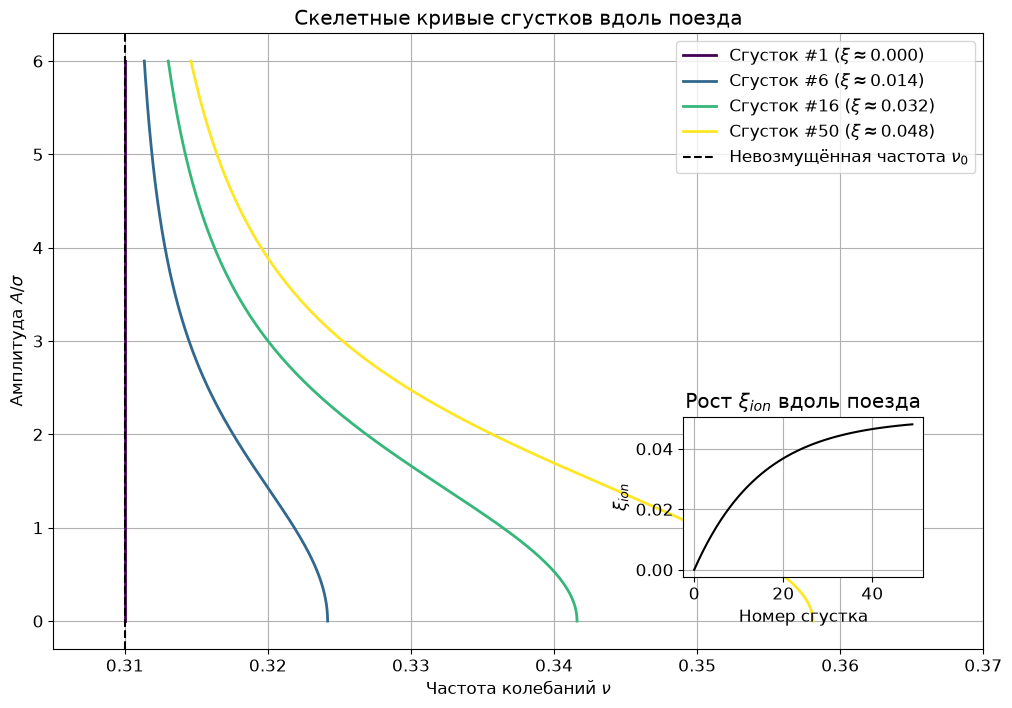

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def tune_shift_factor(amplitude, sigma):
    """
    Форм-фактор сдвига частоты от амплитуды (1D Gaussian).
    Убывает от 1 до 0.
    """
    amp = np.array(amplitude)
    J = (amp**2) / (2 * sigma**2)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        factor = (2.0 / J) * (1.0 - np.exp(-J/2.0) * i0(J/2.0))
    
    factor = np.where(J < 1e-5, 1.0, factor)
    return factor

# Параметры
sigma = 1.0
nu_0 = 0.31
n_bunches = 50 # Количество сгустков в поезде

# Модель накопления ионов (насыщение)
bunch_indices = np.arange(n_bunches)
tau_ion = 15.0 # Характерное время накопления (в сгустках)
xi_max = 0.05  # Максимальный сдвиг частоты (в насыщении)

xi_vals = xi_max * (1 - np.exp(-bunch_indices / tau_ion))

# Амплитуды для построения скелетных кривых
amplitudes = np.linspace(0, 6*sigma, 200)

# Визуализация
plt.figure(figsize=(12, 8))

# Выберем несколько сгустков для отображения
indices_to_plot = [0, 5, 15, 49]
colors = plt.cm.viridis(np.linspace(0, 1, len(indices_to_plot)))

for idx, color in zip(indices_to_plot, colors):
    xi = xi_vals[idx]
    
    # Скелетная кривая: nu(A) = nu_0 + xi * Factor(A)
    # Мы строим A(nu)
    nu_curve = nu_0 + xi * tune_shift_factor(amplitudes, sigma)
    
    label = f'Сгусток #{idx+1} ($\\xi \\approx {xi:.3f}$)'
    plt.plot(nu_curve, amplitudes/sigma, color=color, linewidth=2, label=label)
    
    # "Тень" резонанса (схематично)
    # Просто закрасим область под скелетной кривой для наглядности "наклона"
    # plt.fill_betweenx(amplitudes/sigma, nu_0, nu_curve, color=color, alpha=0.1)

plt.axvline(nu_0, color='black', linestyle='--', label='Невозмущённая частота $\\nu_0$')
plt.title('Скелетные кривые сгустков вдоль поезда')
plt.xlabel('Частота колебаний $\\nu$')
plt.ylabel(r'Амплитуда $A / \sigma$')
plt.legend()
plt.grid(True)
plt.xlim(nu_0 - 0.005, nu_0 + xi_max + 0.01)

# Дополнительный график: рост сдвига частоты вдоль поезда
plt.axes([0.65, 0.2, 0.2, 0.2]) # Вставка
plt.plot(bunch_indices, xi_vals, 'k-')
plt.title('Рост $\\xi_{ion}$ вдоль поезда')
plt.xlabel('Номер сгустка')
plt.ylabel('$\\xi_{ion}$')
plt.grid(True)

plt.show()

## Итоги

Вдоль пучка резонансные кривые сгустков расплываются и всё сильнее наклоняются в сторону, определяемую знаком взаимодействия.
Ионное облако фокусирует электронный пучок, частота растёт, и кривые отклоняются от $\nu_0$ в сторону больших $\nu$.
Разные сгустки в пучке имеют разные условия устойчивости и разные рабочие точки, что и составляет содержание ионной неустойчивости в поезде сгустков.